In [2]:
# imports
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# plot settings
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid", palette="muted")

# paths
BASE_DIR = Path("..").resolve()
DATA_PATH = BASE_DIR / "data" / "spam.csv"
FIGURES_DIR = BASE_DIR / "outputs" / "figures"
MODEL_DIR = BASE_DIR / "outputs" / "model"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# random seed
RANDOM_STATE = 42

# step 1 - load raw data

In [3]:
df = pd.read_csv(DATA_PATH, encoding="latin-1")

print(df.shape)
print(df.head())


(5572, 5)
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [4]:
print(df.columns.tolist())


['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


In [5]:
print(df.dtypes)

v1            str
v2            str
Unnamed: 2    str
Unnamed: 3    str
Unnamed: 4    str
dtype: object


In [6]:
null_table = pd.DataFrame({
    'null_count' : df.isnull().sum(),
    'null_percent' : df.isnull().mean()*100
})
print(null_table)

            null_count  null_percent
v1                   0      0.000000
v2                   0      0.000000
Unnamed: 2        5522     99.102656
Unnamed: 3        5560     99.784637
Unnamed: 4        5566     99.892319


In [7]:
print(df.duplicated().sum())

403


In [8]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


# step 2 - data cleaning

In [9]:
# rename columns
df = df.rename(columns={"v1": "label", "v2": "message"})

print(df.columns.tolist())

['label', 'message', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


In [10]:
# drop nullcolumns
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])


In [11]:
print(df.shape)

(5572, 2)


In [12]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [14]:
# drop duplicates
df = df.drop_duplicates()

print(df.shape)

(5169, 2)


In [15]:
# step 3 - text preprocessing
import nltk
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/yubrajparajuli/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/yubrajparajuli/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/yubrajparajuli/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [16]:
import re
import unicodedata

# lowercase
def to_lowercase(text):
    return text.lower()

# strip whitespace
def strip_whitespace(text):
    return text.strip()

# remove extra spaces
def remove_extra_spaces(text):
    return re.sub(r"\s+", " ", text)

# remove tabs and newlines
def remove_tabs_and_newlines(text):
    return text.replace("\t", " ").replace("\n", " ")

# unicode normalization
def normalize_unicode(text):
    return unicodedata.normalize("NFKD", text)

# remove html tags
def remove_html_tags(text):
    return re.sub(r"<.*?>", "", text)

# remove urls
def remove_urls(text):
    return re.sub(r"http\S+|www\S+", "", text)

# remove emails
def remove_emails(text):
    return re.sub(r"\S+@\S+", "", text)

# remove hashtags and mentions
def remove_hashtags_mentions(text):
    return re.sub(r"[@#]\S+", "", text)

# remove special characters
def remove_special_characters(text):
    return re.sub(r"[^a-zA-Z0-9\s]", "", text)

In [17]:
# full preprocessing pipeline
def preprocess(text):
    text = to_lowercase(text)
    text = strip_whitespace(text)
    text = remove_extra_spaces(text)
    text = remove_tabs_and_newlines(text)
    text = normalize_unicode(text)
    text = remove_html_tags(text)
    text = remove_urls(text)
    text = remove_emails(text)
    text = remove_hashtags_mentions(text)
    text = remove_special_characters(text)
    return text

In [18]:
# apply preprocessing to dataset
df["cleaned_message"] = df["message"].apply(preprocess)

print(df[["message", "cleaned_message"]].head())

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                     cleaned_message  
0  go until jurong point crazy available only in ...  
1                            ok lar joking wif u oni  
2  free entry in 2 a wkly comp to win fa cup fina...  
3        u dun say so early hor u c already then say  
4  nah i dont think he goes to usf he lives aroun...  


In [19]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

print(stop_words)
print(len(stop_words))

{"doesn't", 'hadn', 'he', 'm', 'any', 'ma', "i've", 'theirs', "mightn't", "isn't", "we'll", "wouldn't", 'but', 'other', 'whom', 'against', 'don', 'an', 'it', 'himself', 'has', 'at', 'couldn', 'mustn', 'they', "they'll", 'y', 'why', 'here', 'not', 'was', 'yourselves', 'both', 'when', 'didn', "that'll", 'herself', "she'll", 'ours', "he's", 'had', 'of', 'under', 'were', 'will', 'more', "it's", 'too', 'below', 'by', "you'd", "they'd", 'during', "i'm", 'where', 'did', "i'd", 'and', "he'd", 'a', 'yours', 'i', 'their', 'off', 'nor', 'on', "shouldn't", 'are', "you'll", "mustn't", "it'd", 'just', 'your', "should've", 's', 'if', "hadn't", 'before', 'down', 'only', "won't", 'being', "haven't", 'or', 'all', 'further', "weren't", 'that', 've', 'about', 'won', 'above', 'me', "they've", 'again', 'same', 'some', 'what', 'yourself', 'while', 'after', 'our', "couldn't", 'o', 'no', "you've", 'each', 'such', 'until', "she's", 'wasn', 'who', 're', 'myself', 'themselves', 'own', 'be', "we're", 'for', 'ain',

In [20]:
# remove stopwords
def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])

# apply
df["cleaned_message"] = df["cleaned_message"].apply(remove_stopwords)

print(df[["message", "cleaned_message"]].head())

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                     cleaned_message  
0  go jurong point crazy available bugis n great ...  
1                            ok lar joking wif u oni  
2  free entry 2 wkly comp win fa cup final tkts 2...  
3                u dun say early hor u c already say  
4        nah dont think goes usf lives around though  


In [21]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

# stemming
def apply_stemming(text):
    return " ".join([stemmer.stem(word) for word in text.split()])

# apply
df["cleaned_message"] = df["cleaned_message"].apply(apply_stemming)

print(df[["message", "cleaned_message"]].head())

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                     cleaned_message  
0  go jurong point crazi avail bugi n great world...  
1                              ok lar joke wif u oni  
2  free entri 2 wkli comp win fa cup final tkt 21...  
3                u dun say earli hor u c alreadi say  
4          nah dont think goe usf live around though  


In [22]:
print(df[["label", "message", "cleaned_message"]].head(10))
print(df.shape)

  label                                            message  \
0   ham  Go until jurong point, crazy.. Available only ...   
1   ham                      Ok lar... Joking wif u oni...   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...   
3   ham  U dun say so early hor... U c already then say...   
4   ham  Nah I don't think he goes to usf, he lives aro...   
5  spam  FreeMsg Hey there darling it's been 3 week's n...   
6   ham  Even my brother is not like to speak with me. ...   
7   ham  As per your request 'Melle Melle (Oru Minnamin...   
8  spam  WINNER!! As a valued network customer you have...   
9  spam  Had your mobile 11 months or more? U R entitle...   

                                     cleaned_message  
0  go jurong point crazi avail bugi n great world...  
1                              ok lar joke wif u oni  
2  free entri 2 wkli comp win fa cup final tkt 21...  
3                u dun say earli hor u c alreadi say  
4          nah dont think goe usf live aro

In [23]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

sample = "free entry wkly comp winning entitled receiving"

# stemming result
stemmed = " ".join([stemmer.stem(word) for word in sample.split()])
print("stemming:     ", stemmed)

# lemmatization result
lemmatized = " ".join([lemmatizer.lemmatize(word) for word in sample.split()])
print("lemmatization:", lemmatized)

stemming:      free entri wkli comp win entitl receiv
lemmatization: free entry wkly comp winning entitled receiving


In [24]:
# apply lemmatization instead of stemming
df["cleaned_message"] = df["message"].apply(preprocess)
df["cleaned_message"] = df["cleaned_message"].apply(remove_stopwords)
df["cleaned_message"] = df["cleaned_message"].apply(
    lambda text: " ".join([lemmatizer.lemmatize(word) for word in text.split()])
)

print(df[["message", "cleaned_message"]].head())

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                     cleaned_message  
0  go jurong point crazy available bugis n great ...  
1                            ok lar joking wif u oni  
2  free entry 2 wkly comp win fa cup final tkts 2...  
3                u dun say early hor u c already say  
4           nah dont think go usf life around though  


In [25]:
print(df.shape)
print(df["label"].value_counts())

(5169, 3)
label
ham     4516
spam     653
Name: count, dtype: int64


# step 4 - EDA

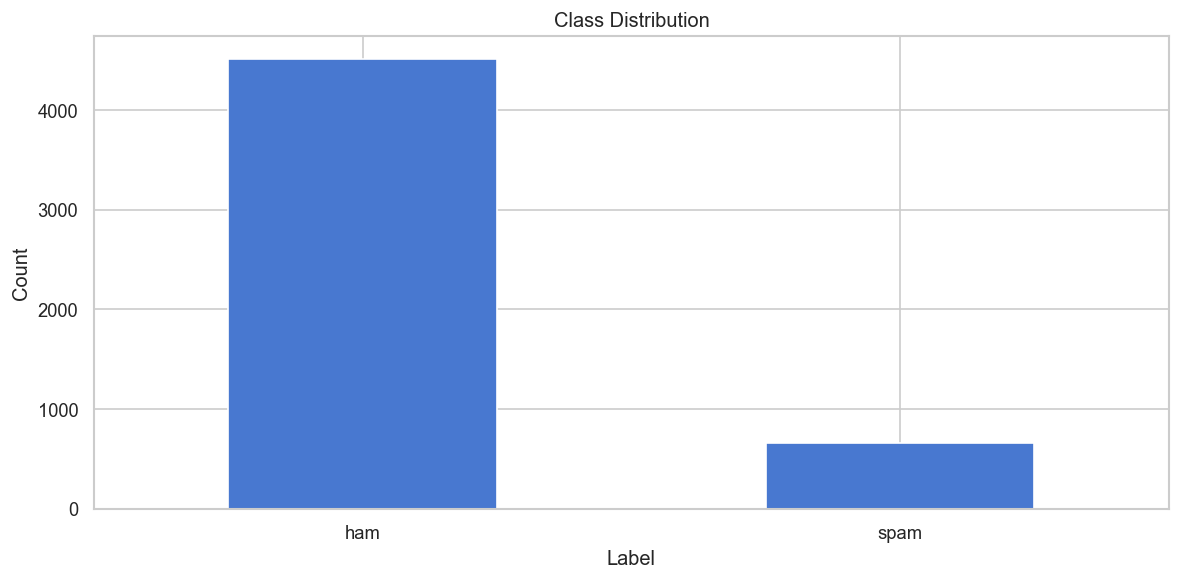

In [26]:
df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png")
plt.show()

In [59]:
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True).round(3) * 100)

label
0    4516
1     653
Name: count, dtype: int64
label
0    87.4
1    12.6
Name: proportion, dtype: float64


In [27]:
# message length
df["message_length"] = df["message"].apply(len)

print(df.groupby("label")["message_length"].describe())

        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4516.0   70.459256  56.358207   2.0   34.0   52.0   90.0  910.0
spam    653.0  137.891271  30.137753  13.0  132.0  149.0  157.0  224.0


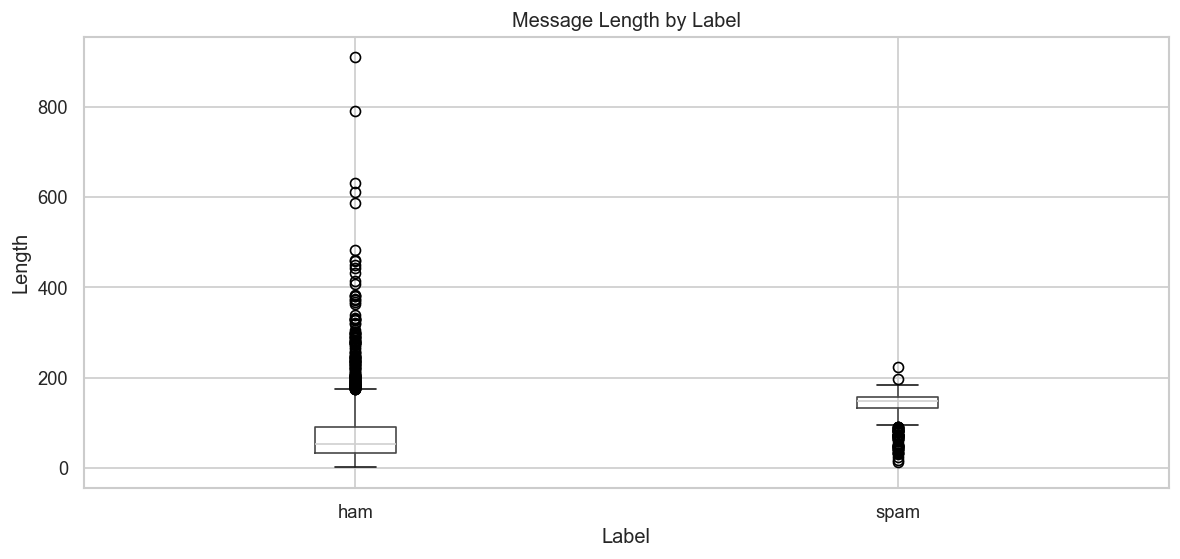

In [28]:
# message length distribution
df.boxplot(column="message_length", by="label")
plt.title("Message Length by Label")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("Length")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "message_length_distribution.png")
plt.show()

In [29]:
# word count
df["word_count"] = df["message"].apply(lambda x: len(x.split()))

print(df.groupby("label")["word_count"].describe())

        count       mean        std  min   25%   50%   75%    max
label                                                            
ham    4516.0  14.134632  11.116240  1.0   7.0  11.0  18.0  171.0
spam    653.0  23.681470   5.967672  2.0  22.0  25.0  28.0   35.0


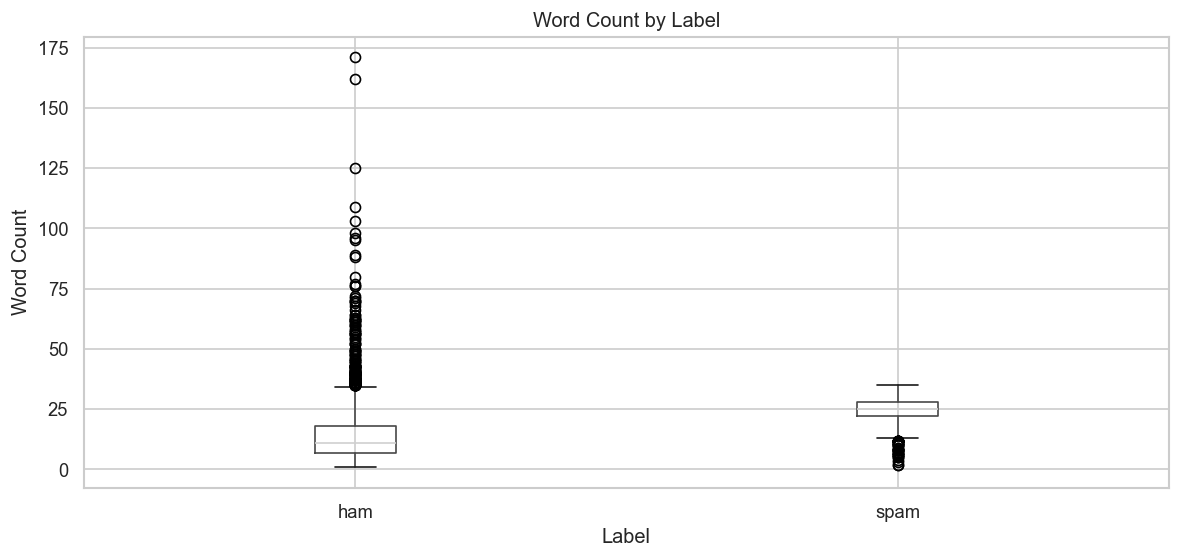

In [30]:
# word count distribution
df.boxplot(column="word_count", by="label")
plt.title("Word Count by Label")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("Word Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "word_count_distribution.png")
plt.show()

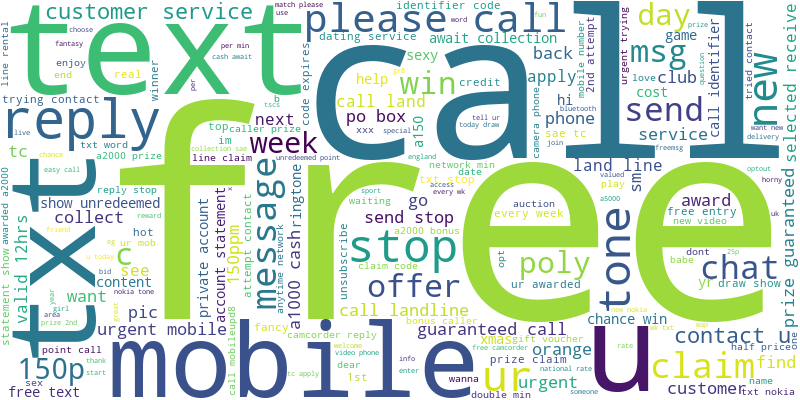

In [31]:
from wordcloud import WordCloud

# spam words
spam_words = " ".join(df[df["label"] == "spam"]["cleaned_message"])

WordCloud(width=800, height=400, background_color="white").generate(spam_words).to_image()

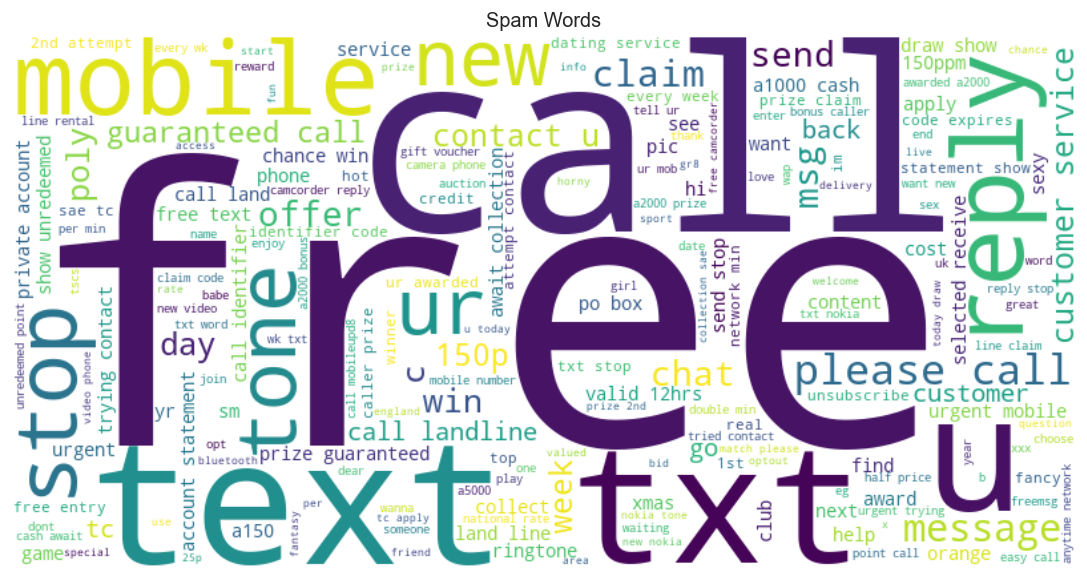

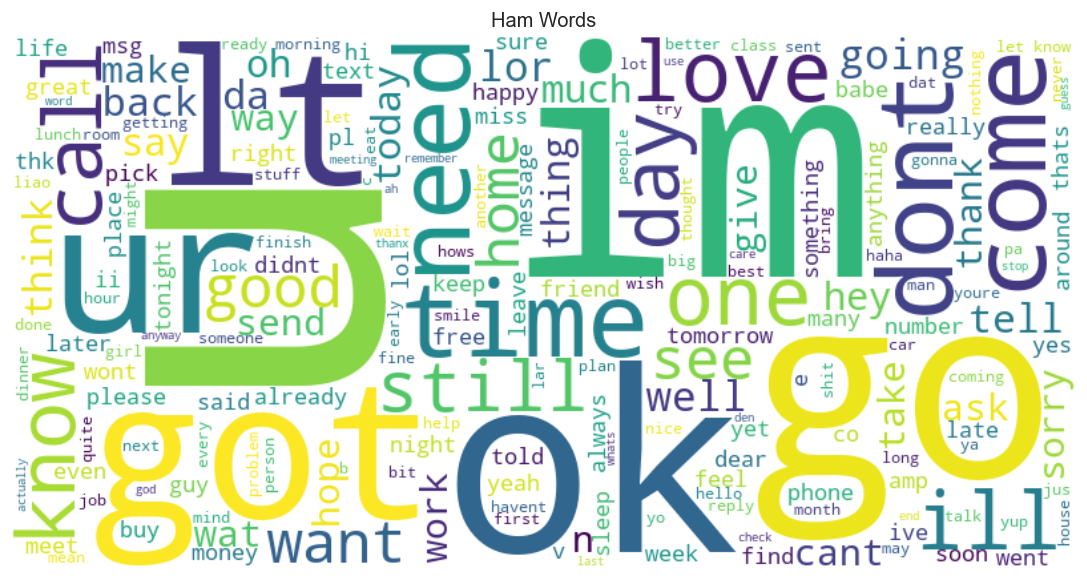

In [32]:
from wordcloud import WordCloud

# spam wordcloud
spam_words = " ".join(df[df["label"] == "spam"]["cleaned_message"])
wordcloud_spam = WordCloud(width=800, height=400, background_color="white").generate(spam_words)

plt.imshow(wordcloud_spam, interpolation="bilinear")
plt.axis("off")
plt.title("Spam Words")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "wordcloud_spam.png")
plt.show()

# ham wordcloud
ham_words = " ".join(df[df["label"] == "ham"]["cleaned_message"])
wordcloud_ham = WordCloud(width=800, height=400, background_color="white").generate(ham_words)

plt.imshow(wordcloud_ham, interpolation="bilinear")
plt.axis("off")
plt.title("Ham Words")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "wordcloud_ham.png")
plt.show()

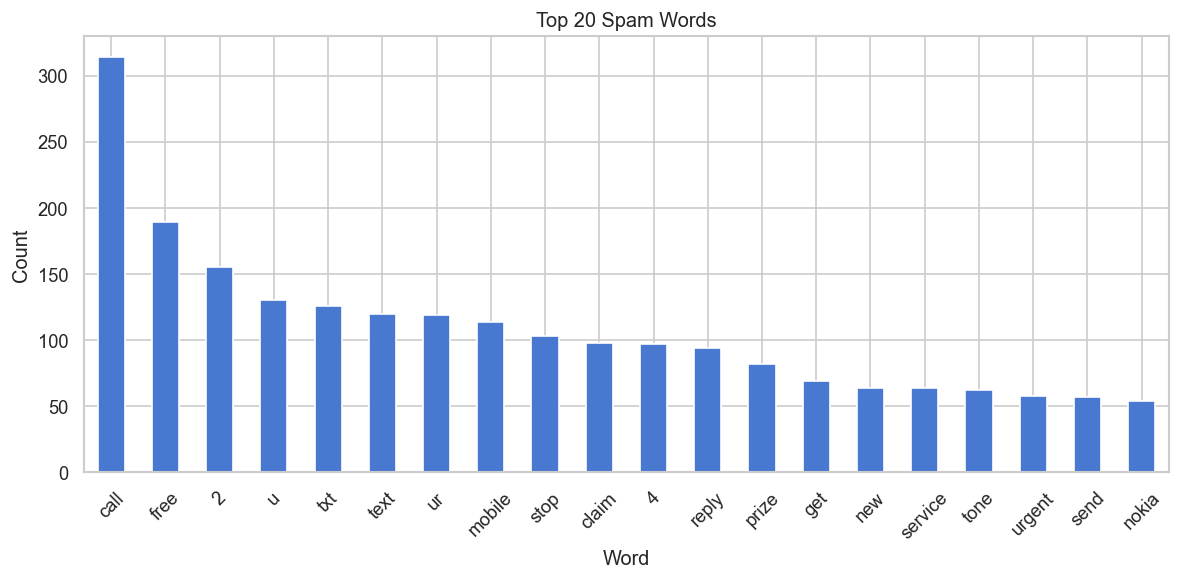

In [33]:
from collections import Counter

# top 20 spam words
spam_words = " ".join(df[df["label"] == "spam"]["cleaned_message"]).split()
spam_top20 = Counter(spam_words).most_common(20)
spam_df = pd.DataFrame(spam_top20, columns=["word", "count"])

spam_df.plot(kind="bar", x="word", y="count", legend=False)
plt.title("Top 20 Spam Words")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top20_spam_words.png")
plt.show()

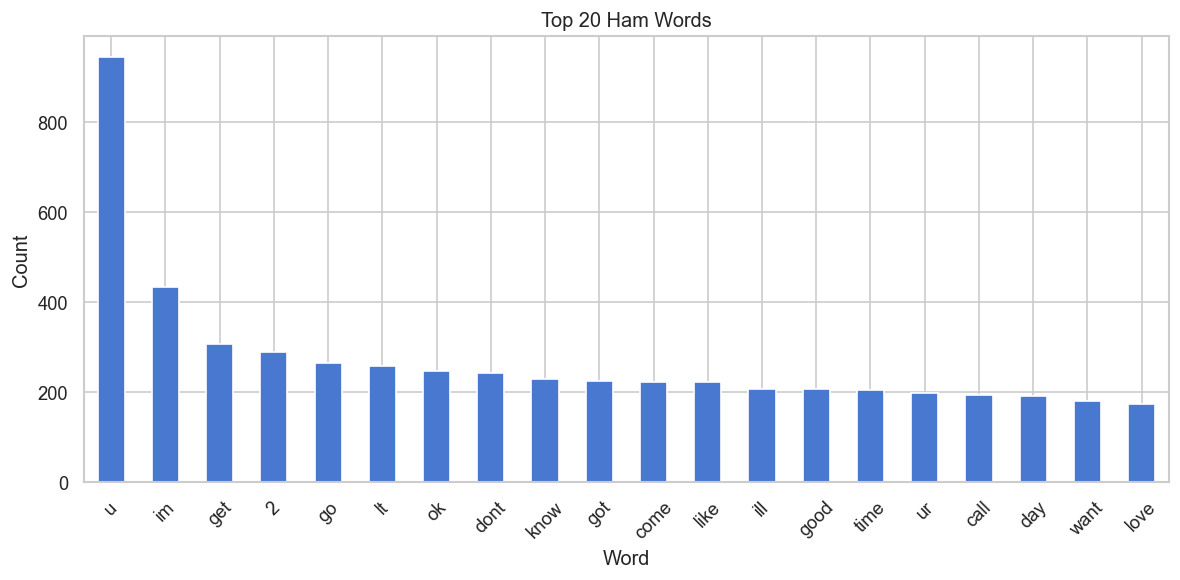

In [34]:
# top 20 ham words
ham_words = " ".join(df[df["label"] == "ham"]["cleaned_message"]).split()
ham_top20 = Counter(ham_words).most_common(20)
ham_df = pd.DataFrame(ham_top20, columns=["word", "count"])

ham_df.plot(kind="bar", x="word", y="count", legend=False)
plt.title("Top 20 Ham Words")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top20_ham_words.png")
plt.show()

In [35]:
# punctuation count
df["punct_count"] = df["message"].apply(lambda x: sum(1 for c in x if c in "!?£$@#%&*"))

print(df.groupby("label")["punct_count"].describe())

        count      mean       std  min  25%  50%  75%   max
label                                                      
ham    4516.0  0.716785  1.582488  0.0  0.0  0.0  1.0  55.0
spam    653.0  1.814701  1.920418  0.0  1.0  1.0  3.0  20.0


In [36]:
# digit count
df["digit_count"] = df["message"].apply(lambda x: sum(1 for c in x if c.isdigit()))

print(df.groupby("label")["digit_count"].describe())

        count       mean       std  min  25%   50%   75%   max
label                                                         
ham    4516.0   0.290301  1.011825  0.0  0.0   0.0   0.0  23.0
spam    653.0  15.447167  8.924653  0.0  9.0  16.0  22.0  47.0


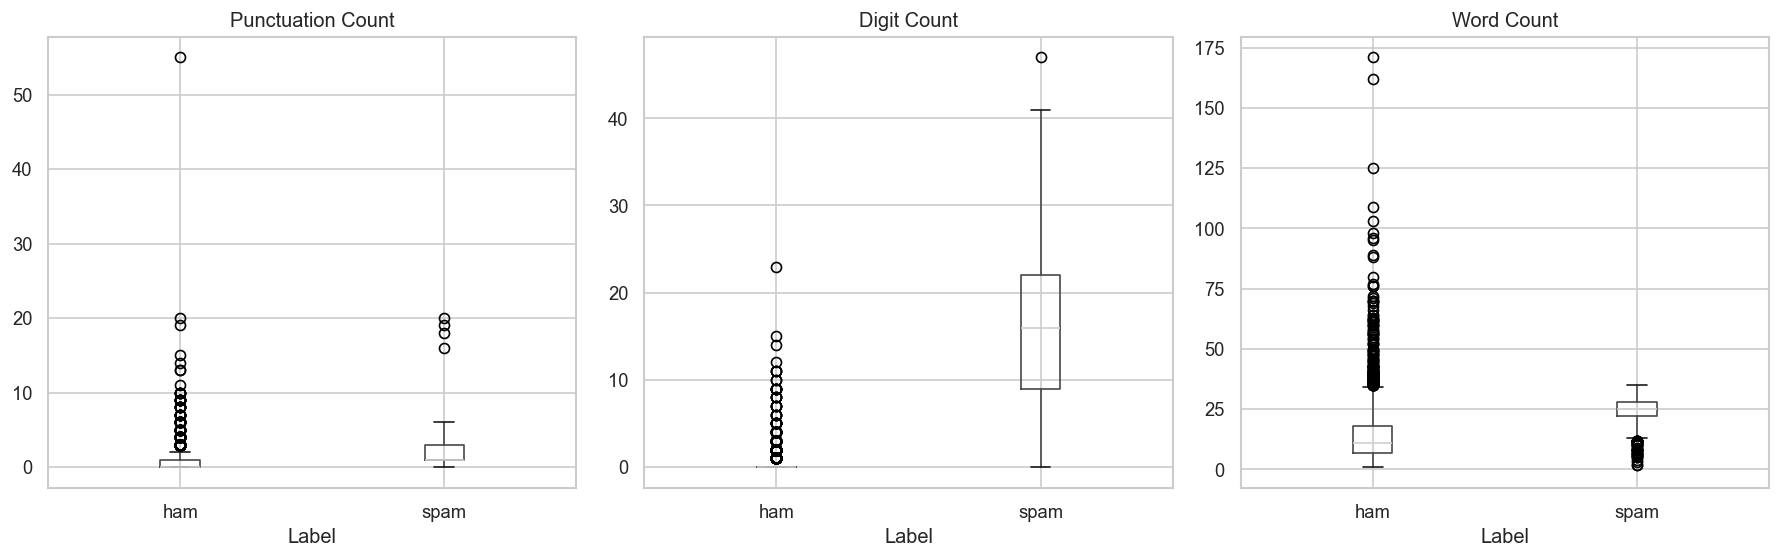

In [37]:
# feature comparison plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df.boxplot(column="punct_count", by="label", ax=axes[0])
axes[0].set_title("Punctuation Count")
axes[0].set_xlabel("Label")

df.boxplot(column="digit_count", by="label", ax=axes[1])
axes[1].set_title("Digit Count")
axes[1].set_xlabel("Label")

df.boxplot(column="word_count", by="label", ax=axes[2])
axes[2].set_title("Word Count")
axes[2].set_xlabel("Label")

plt.suptitle("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_comparison.png")
plt.show()

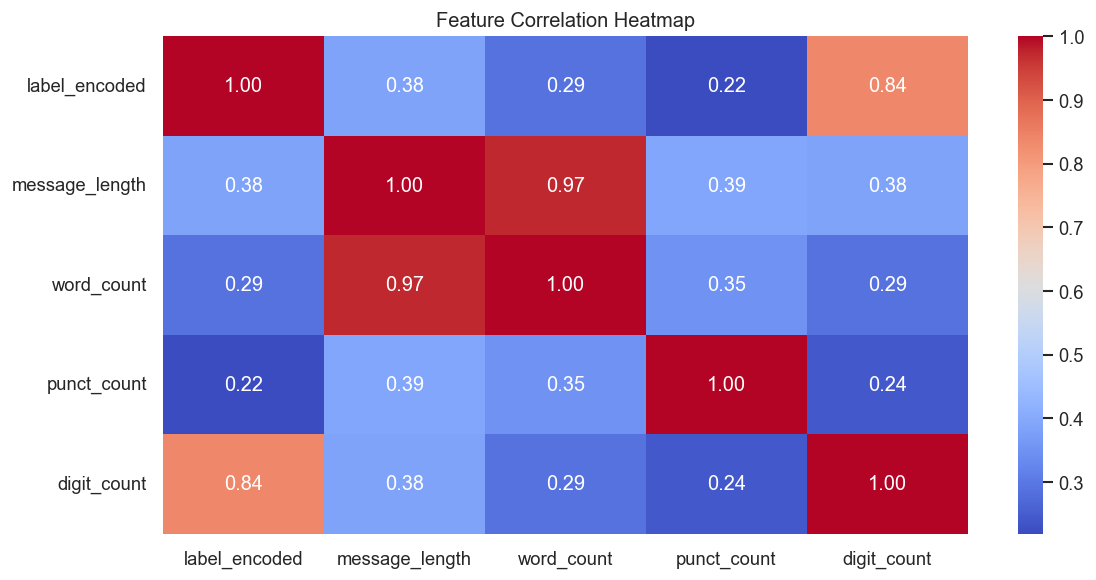

In [38]:
# correlation heatmap
df["label_encoded"] = df["label"].map({"ham": 0, "spam": 1})

corr = df[["label_encoded", "message_length", "word_count", "punct_count", "digit_count"]].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap.png")
plt.show()

# step 5 - feature engineering

In [39]:
# encode label
df["label_encoded"] = df["label"].map({"ham": 0, "spam": 1})

print(df["label_encoded"].value_counts())

label_encoded
0    4516
1     653
Name: count, dtype: int64


In [40]:
print(df.columns.tolist())

['label', 'message', 'cleaned_message', 'message_length', 'word_count', 'punct_count', 'digit_count', 'label_encoded']


In [41]:
df = df.drop(columns=["label", "message"])

print(df.columns.tolist())

['cleaned_message', 'message_length', 'word_count', 'punct_count', 'digit_count', 'label_encoded']


In [42]:
df = df.rename(columns={
    "cleaned_message": "text",
    "label_encoded": "label"
})

print(df.columns.tolist())

['text', 'message_length', 'word_count', 'punct_count', 'digit_count', 'label']


In [43]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("train size:", X_train.shape)
print("test size:", X_test.shape)
print("train spam ratio:", y_train.mean().round(3))
print("test spam ratio:", y_test.mean().round(3))

train size: (4135,)
test size: (1034,)
train spam ratio: 0.126
test spam ratio: 0.127


How spam ratio is calculated from y_train.mean():

y contains 0s (ham) and 1s (spam)
mean() of 0s and 1s = sum of 1s / total count
example: 597 spam out of 4457 total = 597/4457 = 0.134
so mean of binary column directly gives you the ratio of 1s (spam)

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("train matrix shape:", X_train_tfidf.shape)
print("test matrix shape:", X_test_tfidf.shape)

train matrix shape: (4135, 5000)
test matrix shape: (1034, 5000)


In [45]:
# top tfidf features
feature_names = tfidf.get_feature_names_out()
print("total features:", len(feature_names))
print("sample features:", feature_names[:20])

total features: 5000
sample features: ['008704050406' '020603' '0207' '020903' '050703' '0578' '071104'
 '0776xxxxxxx' '07xxxxxxxxx' '0800' '08000776320' '08000839402'
 '08000930705' '08000938767' '08001950382' '08002888812' '08002986906'
 '0844' '08452810073' '0870']


# step 6 - modeling

In [46]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# build pipeline
model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("clf", MultinomialNB())
])

# train
model.fit(X_train, y_train)

print("model trained successfully")


model trained successfully


In [47]:
# handle class imbalance
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

print("sample weight for ham:", sample_weights[y_train == 0][0])
print("sample weight for spam:", sample_weights[y_train == 1][0])

sample weight for ham: 0.5722391364517022
sample weight for spam: 3.960727969348659


In [48]:
# hyperparameter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {"clf__alpha": [0.1, 0.5, 1.0, 2.0, 5.0]}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid_search.fit(X_train, y_train, clf__sample_weight=sample_weights)

print("best alpha:", grid_search.best_params_)
print("best f1 score:", grid_search.best_score_.round(3))

best alpha: {'clf__alpha': 0.1}
best f1 score: 0.851


In [49]:
# train final model with best alpha
best_model = grid_search.best_estimator_
print("final model:", best_model)

final model: Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=5000)),
                ('clf', MultinomialNB(alpha=0.1))])


# step 7 - evaluation

In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = best_model.predict(X_test)

print("accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("precision:", round(precision_score(y_test, y_pred), 3))
print("recall   :", round(recall_score(y_test, y_pred), 3))
print("f1 score :", round(f1_score(y_test, y_pred), 3))

accuracy : 0.963
precision: 0.816
recall   : 0.916
f1 score : 0.863


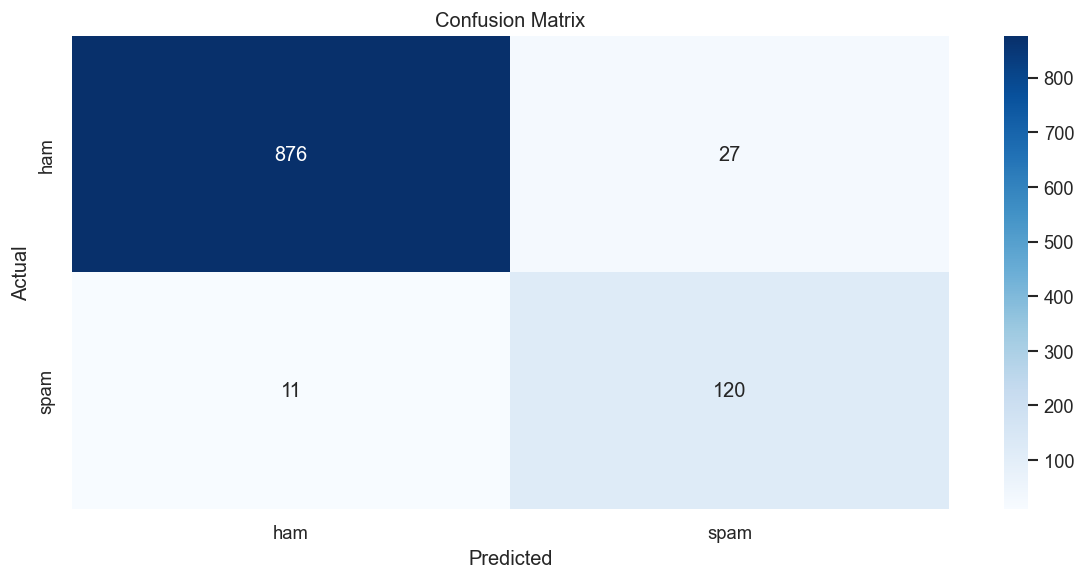

In [51]:
# confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix.png")
plt.show()

In [52]:
# classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

              precision    recall  f1-score   support

         ham       0.99      0.97      0.98       903
        spam       0.82      0.92      0.86       131

    accuracy                           0.96      1034
   macro avg       0.90      0.94      0.92      1034
weighted avg       0.97      0.96      0.96      1034



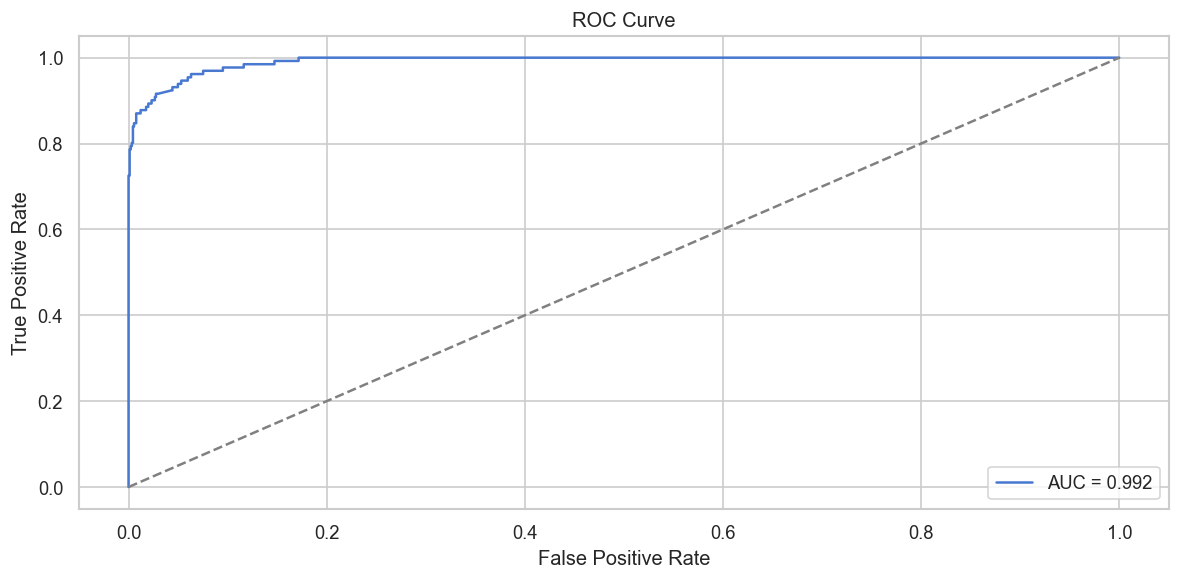

In [53]:
# ROC curve
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {round(auc, 3)}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "roc_curve.png")
plt.show()

# step 8 - error analysis

In [54]:
errors = X_test[y_pred != y_test].to_frame()
errors["actual"] = y_test[y_pred != y_test].map({0: "ham", 1: "spam"})
errors["predicted"] = y_pred[y_pred != y_test]
errors["predicted"] = errors["predicted"].map({0: "ham", 1: "spam"})

print("total errors:", len(errors))
print(errors.head(10))

total errors: 38
                                                   text actual predicted
1600                                      kthen special    ham      spam
5208                                 hiwhat think match    ham      spam
1506  thanks vote sing along star karaoke mobile fre...   spam       ham
4124                      may b approve panalambut post    ham      spam
1245                hello site download song urgent pls    ham      spam
1662  hi ur lookin 4 saucy daytime fun wiv busty mar...   spam       ham
3709                                   town v important    ham      spam
1066                              free call sir waiting    ham      spam
75                             waiting machan call free    ham      spam
2418  madamregret disturbancemight receive reference...    ham      spam


# step 9 - save model


In [55]:
import joblib

joblib.dump(best_model, MODEL_DIR / "spam_detector.joblib")
print("model saved successfully")

model saved successfully


In [56]:
# load and test model
loaded_model = joblib.load(MODEL_DIR / "spam_detector.joblib")

# test messages
test_messages = [
    "Hey, are you coming to the party tonight?",
    "FREE entry! Win £1000 cash prize! Call 08001234567 now!",
    "Ok I will call you later",
    "URGENT! Your mobile number has won a £2000 prize. Claim now!"
]

for msg in test_messages:
    prediction = loaded_model.predict([msg])[0]
    probability = loaded_model.predict_proba([msg])[0]
    label = "spam" if prediction == 1 else "ham"
    print(f"message  : {msg[:50]}")
    print(f"predicted: {label} (spam prob: {round(probability[1], 3)})")
    print()

message  : Hey, are you coming to the party tonight?
predicted: ham (spam prob: 0.008)

message  : FREE entry! Win £1000 cash prize! Call 08001234567
predicted: spam (spam prob: 1.0)

message  : Ok I will call you later
predicted: ham (spam prob: 0.011)

message  : URGENT! Your mobile number has won a £2000 prize. 
predicted: spam (spam prob: 1.0)



# step 10 - cross validation

In [57]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="f1")

print("cv f1 scores:", cv_scores.round(3))
print("mean f1     :", round(cv_scores.mean(), 3))
print("std f1      :", round(cv_scores.std(), 3))

cv f1 scores: [0.94  0.898 0.898 0.918 0.906]
mean f1     : 0.912
std f1      : 0.016


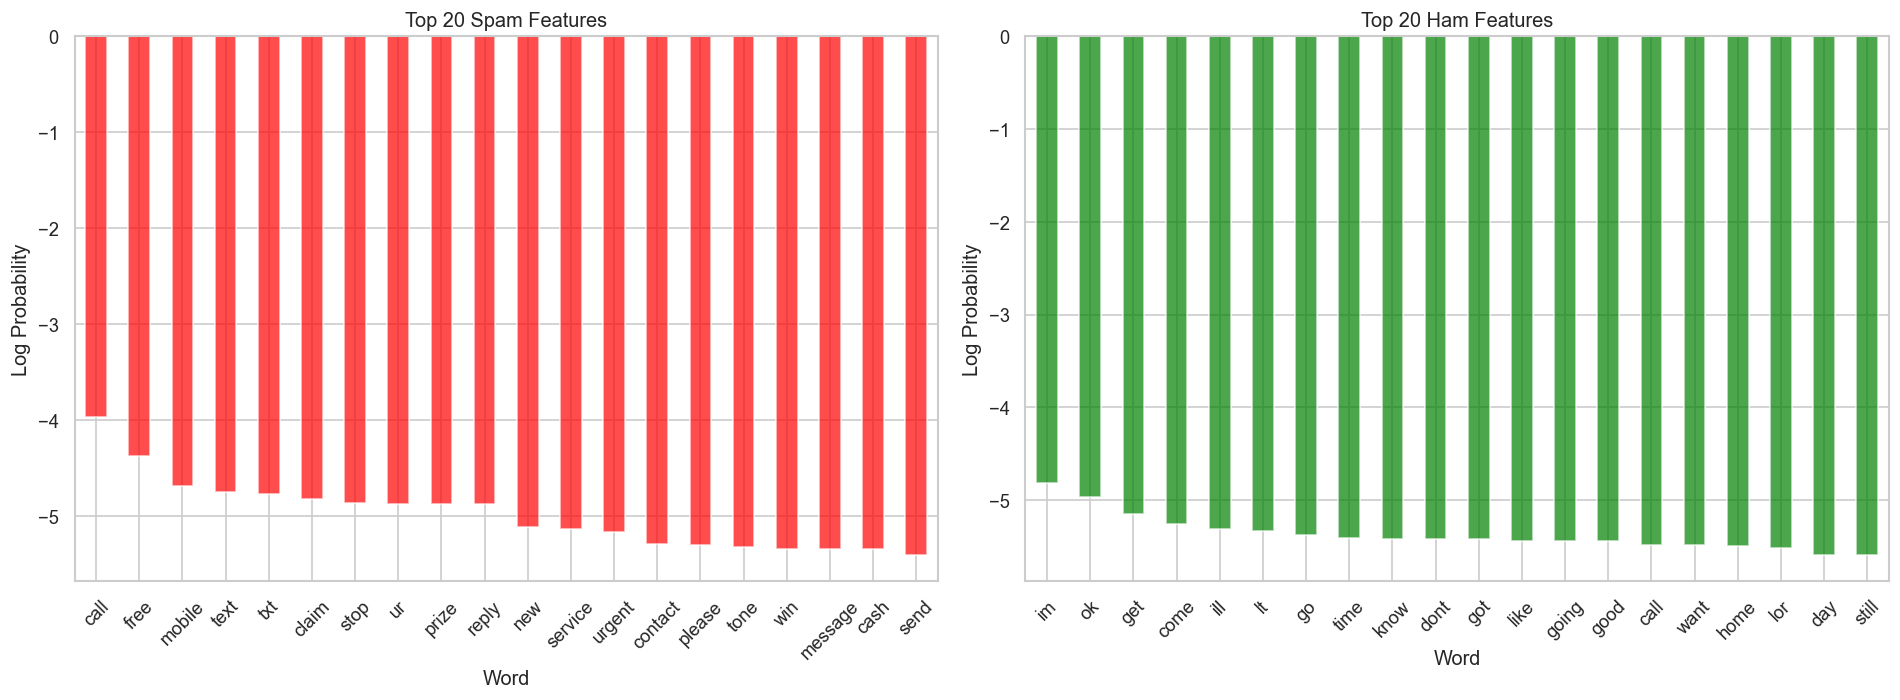

In [58]:
# top tfidf features by class
feature_names = best_model.named_steps["tfidf"].get_feature_names_out()
log_probs = best_model.named_steps["clf"].feature_log_prob_

top_n = 20
top_spam_idx = log_probs[1].argsort()[-top_n:][::-1]
top_ham_idx = log_probs[0].argsort()[-top_n:][::-1]

top_spam_words = [(feature_names[i], log_probs[1][i]) for i in top_spam_idx]
top_ham_words = [(feature_names[i], log_probs[0][i]) for i in top_ham_idx]

spam_df = pd.DataFrame(top_spam_words, columns=["word", "log_prob"])
ham_df = pd.DataFrame(top_ham_words, columns=["word", "log_prob"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

spam_df.plot(kind="bar", x="word", y="log_prob", ax=axes[0], legend=False, color="red", alpha=0.7)
axes[0].set_title("Top 20 Spam Features")
axes[0].set_xlabel("Word")
axes[0].set_ylabel("Log Probability")
axes[0].tick_params(axis="x", rotation=45)

ham_df.plot(kind="bar", x="word", y="log_prob", ax=axes[1], legend=False, color="green", alpha=0.7)
axes[1].set_title("Top 20 Ham Features")
axes[1].set_xlabel("Word")
axes[1].set_ylabel("Log Probability")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_tfidf_features.png")
plt.show()